# Continuous Control

---

You are welcome to use this coding environment to train your agent for the project.  Follow the instructions below to get started!

### 0. Clean Up the Zombie Processes
At the end of this notebook, when you execute `env.close()`, it does not clean up the environment completely. Instead, the Unity environment process becomes a "zombie" process. A zombie process is one that has completed execution but still has an entry in the process table because its parent process hasn’t properly reaped it.
You can yourself verify this by running these commands in the terminal. Find the parent process ID (PPID) of the zombie process:
```bash
ps -o pid,ppid,stat,cmd | grep Reacher
```
If the parent process (PPID) is not 1, kill it to clean up the zombie process:
```bash
kill -9 <PPID>
```
Below is the equivalent Python code that checks for and cleans zombie processes using `psutil`. **You need run the cell below only when you restart the Unity environment.** 

> **NOTE**: The code cell below will also kill the Kernel. You should restart it when required.

### 1. Start the Environment

Run the next code cell to install a few packages.  This line will take a few minutes to run!

In [1]:
!pip -q install .

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


The environments corresponding to both versions of the environment are already saved in the Workspace and can be accessed at the file paths provided below.  

Please select one of the two options below for loading the environment.

In [1]:
from unityagents import UnityEnvironment
import numpy as np

# select this option to load version 1 (with a single agent) of the environment
#
# select this option to load version 2 (with 20 agents) of the environment
env = UnityEnvironment(file_name='/data/Reacher_Linux_NoVis/Reacher.x86_64')

Found path: /data/Reacher_Linux_NoVis/Reacher.x86_64
Mono path[0] = '/data/Reacher_Linux_NoVis/Reacher_Data/Managed'
Mono config path = '/data/Reacher_Linux_NoVis/Reacher_Data/MonoBleedingEdge/etc'
Preloaded 'libgrpc_csharp_ext.x64.so'
Unable to preload the following plugins:
	libgrpc_csharp_ext.x86.so
Logging to /home/student/.config/unity3d/Unity Technologies/Unity Environment/Player.log


INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		goal_size -> 5.0
		goal_speed -> 1.0
Unity brain name: ReacherBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 33
        Number of stacked Vector Observation: 1
        Vector Action space type: continuous
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


Environments contain **_brains_** which are responsible for deciding the actions of their associated agents. Here we check for the first brain available, and set it as the default brain we will be controlling from Python.

In [2]:
# get the default brain
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

### 2. Examine the State and Action Spaces

Run the code cell below to print some information about the environment.

In [3]:
# reset the environment
env_info = env.reset(train_mode=True)[brain_name]

# number of agents
num_agents = len(env_info.agents)
print('Number of agents:', num_agents)

# size of each action
action_size = brain.vector_action_space_size
print('Size of each action:', action_size)

# examine the state space 
states = env_info.vector_observations
state_size = states.shape[1]
print('There are {} agents. Each observes a state with length: {}'.format(states.shape[0], state_size))
print('The state for the first agent looks like:', states[0])

Number of agents: 20
Size of each action: 4
There are 20 agents. Each observes a state with length: 33
The state for the first agent looks like: [ 0.00000000e+00 -4.00000000e+00  0.00000000e+00  1.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -4.37113883e-08  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.00000000e+01  0.00000000e+00
  1.00000000e+00 -0.00000000e+00 -0.00000000e+00 -4.37113883e-08
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  5.75471878e+00 -1.00000000e+00
  5.55726624e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
 -1.68164849e-01]


### 3. Take Random Actions in the Environment

In the next code cell, you will learn how to use the Python API to control the agent and receive feedback from the environment.

Note that **in this coding environment, you will not be able to watch the agents while they are training**, and you should set `train_mode=True` to restart the environment.

In [5]:
# env_info = env.reset(train_mode=True)[brain_name]      # reset the environment    
# states = env_info.vector_observations                  # get the current state (for each agent)
# scores = np.zeros(num_agents)                          # initialize the score (for each agent)
# while True:
#     actions = np.random.randn(num_agents, action_size) # select an action (for each agent)
#     actions = np.clip(actions, -1, 1)                  # all actions between -1 and 1
#     env_info = env.step(actions)[brain_name]           # send all actions to tne environment
#     next_states = env_info.vector_observations         # get next state (for each agent)
#     rewards = env_info.rewards                         # get reward (for each agent)
#     dones = env_info.local_done                        # see if episode finished
#     scores += env_info.rewards                         # update the score (for each agent)
#     states = next_states                               # roll over states to next time step
#     if np.any(dones):                                  # exit loop if episode finished
#         break
# print('Total score (averaged over agents) this episode: {}'.format(np.mean(scores)))

When finished, you can close the environment.

In [8]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


### 4. It's Your Turn!

Now it's your turn to train your own agent to solve the environment!  A few **important notes**:
- When training the environment, set `train_mode=True`, so that the line for resetting the environment looks like the following:
```python
env_info = env.reset(train_mode=True)[brain_name]
```
- To structure your work, you're welcome to work directly in this Jupyter notebook, or you might like to start over with a new file!  You can see the list of files in the workspace by clicking on **_Jupyter_** in the top left corner of the notebook.
- In this coding environment, you will not be able to watch the agents while they are training.  However, **_after training the agents_**, you can download the saved model weights to watch the agents on your own machine! 

In [4]:
#model.py 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    """
    Orthogonal initialization: The 'secret sauce' for PPO. 
    It prevents gradients from vanishing/exploding better than standard uniform.
    """
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class PPO_Actor(nn.Module):
    def __init__(self, state_size, action_size, seed, fc1_units=256, fc2_units=128):
        super(PPO_Actor, self).__init__()
        self.seed = torch.manual_seed(seed)
        
        # The Neural Network for the Mean (mu)
        self.fc1 = layer_init(nn.Linear(state_size, fc1_units))
        self.fc2 = layer_init(nn.Linear(fc1_units, fc2_units))
        # The final layer uses a smaller std for initialization so actions start near 0
        self.fc_mean = layer_init(nn.Linear(fc2_units, action_size), std=0.01)
        
        # The Standard Deviation (sigma) is a standalone, learnable parameter!
        # We don't pass the state into it. It's just a set of 4 numbers that the network tunes over time.
        self.action_std = nn.Parameter(torch.zeros(1, action_size))

    def forward(self, state, action=None):
        """Outputs a probability distribution, samples an action, and returns its log probability."""
        
        # 1. Calculate the Mean (mu)
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        action_mean = F.tanh(self.fc_mean(x)) # Squashed between -1 and 1
        
        # 2. Calculate the Standard Deviation (sigma)
        # We use softplus to ensure the standard deviation is always a positive number
        action_std = F.softplus(self.action_std)
        
        # 3. Create the Probability Distribution (The Bell Curve)
        dist = Normal(action_mean, action_std)
        
        # If we didn't pass in an action, we are interacting with the environment, so we sample one
        if action is None:
            action = dist.sample()
            
        # 4. Calculate the Log Probability of the action
        # We need this for the PPO ratio math later!
        action_log_prob = dist.log_prob(action).sum(dim=-1)
        
        # 5. Calculate Entropy (how random the distribution is, used to encourage exploration)
        dist_entropy = dist.entropy().sum(dim=-1)
        
        return action, action_log_prob, dist_entropy


class PPO_Critic(nn.Module):
    def __init__(self, state_size, seed, fc1_units=256, fc2_units=128):
        super(PPO_Critic, self).__init__()
        self.seed = torch.manual_seed(seed)
        
        # The Critic ONLY takes the state now. No action required!
        self.fc1 = layer_init(nn.Linear(state_size, fc1_units))
        self.fc2 = layer_init(nn.Linear(fc1_units, fc2_units))
        self.fc_value = layer_init(nn.Linear(fc2_units, 1), std=1.0)

    def forward(self, state):
        """Maps a state to a single V(s) value."""
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc_value(x)

In [5]:
import sys
print(sys.executable)


/usr/bin/python3


In [6]:
#memory.py
import torch
import numpy as np

class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.dones = []

    def store(self, state, action, log_prob, reward, value, done):
        """Saves a single step of experience for all 20 agents."""
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(done)

    def clear(self):
        """Empties the buffer after the network has updated."""
        self.states.clear()
        self.actions.clear()
        self.log_probs.clear()
        self.rewards.clear()
        self.values.clear()
        self.dones.clear()

    def generate_batches(self, batch_size):
        """Flattens the 20-agent trajectories and chunks them into mini-batches."""
        # Stack lists of arrays into single massive tensors
        states = torch.cat(self.states, dim=0)
        actions = torch.cat(self.actions, dim=0)
        log_probs = torch.cat(self.log_probs, dim=0)
        values = torch.cat(self.values, dim=0)
        
        # Calculate the total number of experiences (e.g., 1000 steps * 20 agents = 20,000)
        total_samples = states.shape[0]
        
        # Generate an array of shuffled indices
        indices = np.arange(total_samples, dtype=np.int64)
        np.random.shuffle(indices)
        
        # Yield mini-batches
        for start_idx in range(0, total_samples, batch_size):
            end_idx = min(start_idx + batch_size, total_samples)
            batch_indices = indices[start_idx:end_idx]
            
            yield (
                states[batch_indices],
                actions[batch_indices],
                log_probs[batch_indices],
                values[batch_indices],
                batch_indices # We return indices to map advantages/returns later
            )

In [7]:
#agent.py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
# from model import PPO_Actor, PPO_Critic
# from memory import RolloutBuffer

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
class PPOAgent:
    def __init__(self, state_size, action_size, seed):
        self.seed = torch.manual_seed(seed)
        
        # Hyperparameters (The standard PPO defaults that "just work")
        self.gamma = 0.99         # Discount factor
        self.lam = 0.95           # GAE smoothing parameter
        self.clip_ratio = 0.2     # PPO clipping parameter (epsilon)
        self.ppo_epochs = 10      # How many times to loop over the data
        self.batch_size = 256     # Mini-batch size for gradient descent
        self.lr_actor = 3e-4
        self.lr_critic = 3e-4
        self.c1 = 0.5             # Value loss coefficient
        self.c2 = 0.01            # Entropy coefficient (exploration bonus)
        
        # Initialize Networks & Memory
        self.actor = PPO_Actor(state_size, action_size, seed).to(device)
        self.critic = PPO_Critic(state_size, seed).to(device)
        self.optimizer_actor = optim.Adam(self.actor.parameters(), lr=self.lr_actor)
        self.optimizer_critic = optim.Adam(self.critic.parameters(), lr=self.lr_critic)
        self.memory = RolloutBuffer()

    def act(self, state):
        """Passes state through networks to get actions, probabilities, and value estimates."""
        state = torch.from_numpy(state).float().to(device)
        
        # We use torch.no_grad() because we don't want to calculate gradients during gameplay
        with torch.no_grad():
            action, log_prob, _ = self.actor(state)
            value = self.critic(state)
            
        return action.cpu().numpy(), log_prob, value

    def compute_gae(self, next_value):
        """The telescoping GAE math we discussed! Calculates Advantages and Returns."""
        rewards = self.memory.rewards
        values = self.memory.values
        dones = self.memory.dones
        
        advantages = []
        gae = 0
        
        # Loop backwards through the trajectory
        for t in reversed(range(len(rewards))):
            # If the episode ended, the value of the next state is 0
            next_val = next_value if t == len(rewards) - 1 else values[t + 1]
            non_terminal = 1.0 - dones[t]
            
            # delta = r_t + gamma * V(s_{t+1}) - V(s_t)
            delta = rewards[t] + self.gamma * next_val * non_terminal - values[t]
            
            # GAE telescoping sum
            gae = delta + self.gamma * self.lam * non_terminal * gae
            advantages.insert(0, gae)
            
        # Convert lists to tensors
        advantages = torch.cat(advantages, dim=0).to(device)
        values = torch.cat(values, dim=0).to(device)
        
        # The true Return is simply the calculated Advantage + the Critic's original guess
        returns = advantages + values
        
        # Normalize advantages (standard RL trick to stabilize gradients)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        return advantages, returns

    def learn(self, next_state):
        """The Master PPO Update Loop."""
        # 1. Get the Critic's guess for the state AFTER the rollout ended
        next_state = torch.from_numpy(next_state).float().to(device)
        with torch.no_grad():
            next_value = self.critic(next_state)
            
        # 2. Calculate Advantages and Returns via GAE
        advantages, returns = self.compute_gae(next_value)
        
        # 3. Train for multiple epochs on this exact batch of data
        for _ in range(self.ppo_epochs):
            for states, old_actions, old_log_probs, old_values, indices in self.memory.generate_batches(self.batch_size):
                
                # Fetch the advantages and returns specifically for this mini-batch
                batch_advantages = advantages[indices].squeeze() 
                batch_returns = returns[indices].squeeze()
                # Evaluate the old actions using the NEW, currently updating network
                _, new_log_probs, entropy = self.actor(states, old_actions)
                new_values = self.critic(states).squeeze()
                
                # --- PPO ACTOR LOSS (The Clipping) ---
                # ratio = pi_theta(a|s) / pi_theta_old(a|s)
                ratio = torch.exp(new_log_probs - old_log_probs)
                
                surr1 = ratio * batch_advantages
                surr2 = torch.clamp(ratio, 1.0 - self.clip_ratio, 1.0 + self.clip_ratio) * batch_advantages
                actor_loss = -torch.min(surr1, surr2).mean()
                
                # --- PPO CRITIC LOSS ---
                critic_loss = nn.MSELoss()(new_values, batch_returns)
                
                # --- TOTAL LOSS ---
                loss = actor_loss + (self.c1 * critic_loss) - (self.c2 * entropy.mean())
                
                # Backpropagation
                self.optimizer_actor.zero_grad()
                self.optimizer_critic.zero_grad()
                loss.backward()
                # Clip gradients to prevent huge spikes
                nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
                nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
                self.optimizer_actor.step()
                self.optimizer_critic.step()
                
        # 4. Throw the data in the trash so we collect fresh, on-policy data next time
        self.memory.clear()

cuda:0


INFO:matplotlib.font_manager:generated new fontManager


Episode 10	Average Score (Last 100): 0.58	Current Score: 1.45
Episode 20	Average Score (Last 100): 1.83	Current Score: 4.66
Episode 30	Average Score (Last 100): 4.22	Current Score: 14.07
Episode 40	Average Score (Last 100): 8.82	Current Score: 29.27
Episode 50	Average Score (Last 100): 13.52	Current Score: 34.64
Episode 60	Average Score (Last 100): 17.41	Current Score: 38.17
Episode 70	Average Score (Last 100): 20.43	Current Score: 38.94
Episode 80	Average Score (Last 100): 22.72	Current Score: 38.96
Episode 90	Average Score (Last 100): 24.52	Current Score: 38.84
Episode 100	Average Score (Last 100): 25.96	Current Score: 39.14
Episode 110	Average Score (Last 100): 29.80	Current Score: 39.26
Episode 111	Average Score (Last 100): 30.18	Current Score: 39.06
Environment solved in 11 episodes!	Average Score: 30.18


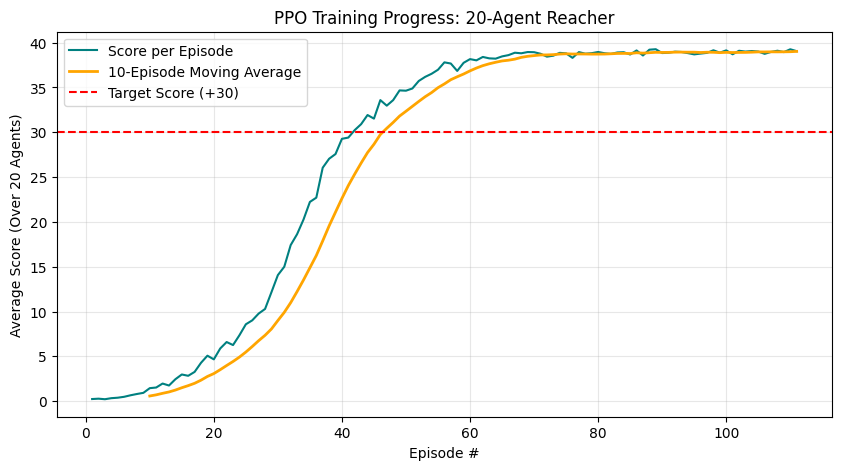

In [8]:
#train.py
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
#from agent import PPOAgent
# Assuming env is already instantiated via UnityEnvironment as in your notebook

brain_name = env.brain_names[0]
brain = env.brains[brain_name]
env_info = env.reset(train_mode=True)[brain_name]
num_agents = len(env_info.agents)
state_size = env_info.vector_observations.shape[1]
action_size = brain.vector_action_space_size

# Initialize our custom PPO Agent
agent = PPOAgent(state_size=state_size, action_size=action_size, seed=42)

def train_ppo(n_episodes=300, max_t=1000):
    scores_window = deque(maxlen=100) # Tracks the last 100 episodes
    all_scores = []                   # Tracks every episode for the final plot
    
    for i_episode in range(1, n_episodes+1):
        env_info = env.reset(train_mode=True)[brain_name]
        states = env_info.vector_observations
        episode_scores = np.zeros(num_agents)
        
        # 1. Collect a Trajectory (Rollout)
        for t in range(max_t):
            # Ask the agent what to do
            actions, log_probs, values = agent.act(states)
            clipped_actions = np.clip(actions, -1, 1)
            
            # Send actions to the Unity environment
            env_info = env.step(clipped_actions)[brain_name]
            next_states = env_info.vector_observations
            rewards = env_info.rewards
            dones = env_info.local_done
            
            # Format the data for PyTorch and store it in our buffer
            agent.memory.store(
                torch.tensor(states).float().to(device),
                torch.tensor(actions).float().to(device),
                log_probs,
                torch.tensor(rewards).float().to(device).unsqueeze(1),
                values,
                torch.tensor(dones).float().to(device).unsqueeze(1)
            )
            
            states = next_states
            episode_scores += rewards
            
            if np.any(dones):
                break
                
        # 2. Update the Agent
        # Pass the final next_states so GAE can calculate the very last bootstrap value
        agent.learn(next_states)
        
        # 3. Track Scoring
        # Udacity requires you to take the mean of all 20 agents for the episode score
        mean_score = np.mean(episode_scores)
        scores_window.append(mean_score)
        all_scores.append(mean_score)
        
        print(f'\rEpisode {i_episode}\tAverage Score (Last 100): {np.mean(scores_window):.2f}\tCurrent Score: {mean_score:.2f}', end="")
        
        if i_episode % 10 == 0:
            print(f'\rEpisode {i_episode}\tAverage Score (Last 100): {np.mean(scores_window):.2f}')
            
        if np.mean(scores_window) >= 30.0:
            print(f'\nEnvironment solved in {i_episode - 100} episodes!\tAverage Score: {np.mean(scores_window):.2f}')
            torch.save(agent.actor.state_dict(), 'checkpoint_actor.pth')
            torch.save(agent.critic.state_dict(), 'checkpoint_critic.pth')
            break
            
    return all_scores

# Run the training loop!
scores = train_ppo()

# --- Plotting for the Final Report ---
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
plt.plot(np.arange(1, len(scores)+1), scores, color='teal', label='Score per Episode')

# Add a moving average line (looks great on reports)
import pandas as pd
moving_avg = pd.Series(scores).rolling(window=10).mean()
plt.plot(np.arange(1, len(scores)+1), moving_avg, color='orange', linewidth=2, label='10-Episode Moving Average')

# Add the target line
plt.axhline(y=30, color='r', linestyle='--', label='Target Score (+30)')

plt.title('PPO Training Progress: 20-Agent Reacher')
plt.ylabel('Average Score (Over 20 Agents)')
plt.xlabel('Episode #')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save the plot for your submission
fig.savefig("PPO_scores_plot.png", dpi=300)

In [9]:
from IPython.display import FileLink, display

display(FileLink('checkpoint_actor.pth'))
display(FileLink('checkpoint_critic.pth'))
display(FileLink('PPO_scores_plot.png'))

Click the links below to download your files:


/workspace/home/python/checkpoint_actor.pth

/workspace/home/python/checkpoint_critic.pth

/workspace/home/python/PPO_scores_plot.png